# CLUSTERING DEL RIESGO ENERGÉTICO EN LAS ZNI

El presente cuaderno contiene el algoritmo no supervisado de Machine Learning para la identificación del riesgo energético en las Zonas No Interconectadas. Con el fin de focalizar la política pública, se agrupan los municipios según su consumo y sus horas de servicio, permitiendo observar de manera cuantitativa los distintos perfiles de riesgo.

**Objetivo:** identificar perfiles de riesgo energético mediante clustering (insumo para los lineamientos de política y el tablero de control).

## Bibliotecas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Datos

In [3]:
df = pd.read_csv("../data/processed/servicio_electrico_limpio.csv")
df.head()

,id_departamento,departamento,id_municipio,municipio,id_localidad,localidad,anio_servicio,mes_servicio,energia_activa,energia_reactiva,potencia_maxima,dia_demanda_max,fecha_demanda_max,promedio_horas,municipio_original
0,91,amazonas,91001,leticia,91001000,leticia (leticia - amazonas),2020,1,3930642,1251191,7768.76,lunes,2020-01-27 14:15:00,24.00,leticia
1,91,amazonas,91540,puerto nariño,91540000,puerto nariño (puerto nariño - amazonas),2020,1,103897,36304,227.04,miércoles,2020-01-22 19:15:00,24.00,puerto nariño
2,91,amazonas,91798,tarapacá,91798000,tarapacá (tarapacá (anm) - amazonas),2020,1,22864,9277,88.96,jueves,2020-01-30 19:30:00,10.19,tarapacá (anm)
3,5,antioquia,5873,vigía del fuerte,5873001,san antonio de padua (vigía del fuerte - antio...,2020,1,5617,1381,53.66,jueves,2020-01-23 19:45:00,4.13,vigía del fuerte
4,5,antioquia,5873,vigía del fuerte,5873002,vegáez (vigía del fuerte - antioquia),2020,1,2217,539,39.07,miércoles,2020-01-29 19:45:00,3.17,vigía del fuerte


## Preparación de los datos

La presente agregación permite resumir cada municipio en tres promedios: energía, potencia y horas de servicio. Se excluyen los registros sin servicio para no distorsionar los grupos.

In [4]:
df_mpio = df.groupby("municipio", observed=False).agg(
    energia_media=("energia_activa", "mean"),
    potencia_media=("potencia_maxima", "mean"),
    horas_media=("promedio_horas", "mean")
).dropna()

df_mpio = df_mpio[(df_mpio["energia_media"] > 0) & (df_mpio["horas_media"] > 0)]

df_mpio = df_mpio[~df_mpio.index.isin(["san andrés", "san andres"])]

df_mpio.head()

,energia_media,potencia_media,horas_media
municipio,,,
acandí,350300.014085,89627.017324,16.077487
alto baudó,28219.666667,2893.585124,14.825253
bahía solano,303215.540107,16499.499305,22.845203
bajo baudó,48652.340694,7507.023803,10.035205
barrancominas,43411.797468,6448.686582,13.879251


Nota: se excluye San Andrés del clustering por constituir un sistema estructuralmente distinto (red insular de alto consumo que absorbe un grupo completo). Se analiza por separado en los lineamientos. Además, energía y potencia entran en logaritmo base 10 para que los consumos de miles a millones no dominen el escalado.

## Escalado

El presente paso permite igualar las escalas de las variables, pues la energía se mide en cientos de miles y las horas en decenas. Sin escalado, el algoritmo solo vería la energía.

In [5]:
scaler = StandardScaler()
df_cluster = df_mpio.copy()
df_cluster[["energia_media", "potencia_media"]] = np.log10(df_cluster[["energia_media", "potencia_media"]])
datos = scaler.fit_transform(df_cluster)

### Método del codo

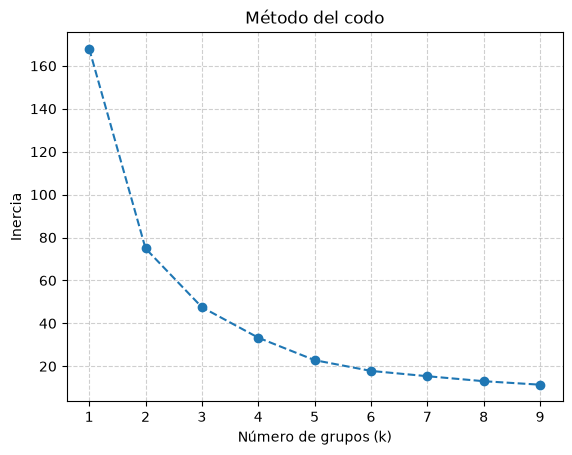

In [6]:
inercia = []
rango_k = range(1, 10)

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(datos)
    inercia.append(modelo.inertia_)

plt.plot(rango_k, inercia, marker="o", linestyle="--")
plt.title("Método del codo")
plt.xlabel("Número de grupos (k)")
plt.ylabel("Inercia")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Silueta

El presente gráfico permite confirmar el número de grupos: valores cercanos a 1 indican municipios bien asignados a su grupo.

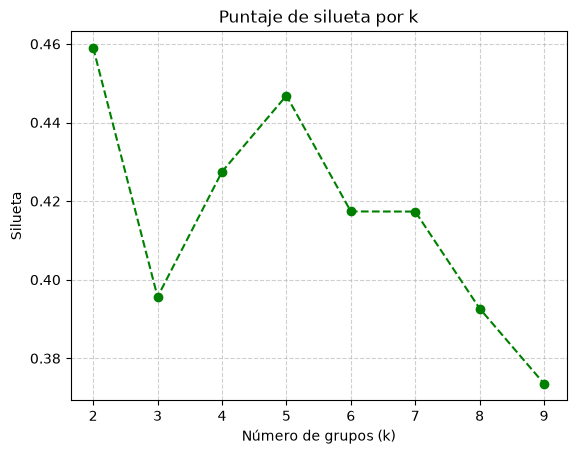

In [7]:
puntajes = []
rango_sil = range(2, 10)

for k in rango_sil:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    grupos = modelo.fit_predict(datos)
    puntajes.append(silhouette_score(datos, grupos))

plt.plot(list(rango_sil), puntajes, marker="o", linestyle="--", color="green")
plt.title("Puntaje de silueta por k")
plt.xlabel("Número de grupos (k)")
plt.ylabel("Silueta")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**Resultado.** El codo se marca alrededor de k = 4 y la silueta lo confirma como un valor competitivo. Por ende, se adoptan cuatro perfiles de riesgo energético.

## Modelo final

In [21]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_mpio["cluster"] = kmeans.fit_predict(datos)

perfiles = df_mpio.groupby("cluster").agg(
    municipios=("horas_media", "count"),
    horas_media=("horas_media", "mean"),
    energia_media=("energia_media", "mean"),
    potencia_media=("potencia_media", "mean")
).round(2).sort_values("horas_media")

perfiles

,municipios,horas_media,energia_media,potencia_media
cluster,,,,
1,18,5.90,7224.34,190.59
2,22,10.24,28523.88,12560.67
0,16,20.49,719232.49,349208.46


**Resultado.** Los perfiles se ordenan de menor a mayor disponibilidad. El grupo más numeroso presenta pocas horas diarias y bajo consumo: riesgo crítico, prioritario para la transición energética justa. En el extremo opuesto, un grupo pequeño supera las 20 horas con alto consumo: riesgo bajo. A lo anterior se suma que los grupos intermedios combinan horas medias con consumos dispares, lo que exige soluciones diferenciadas por territorio.

### Grupos por energía y horas

El presente gráfico permite ver los cuatro grupos separados. El eje de energía va en escala logarítmica porque los consumos van de miles a millones: sin ella, los municipios se amontonan a la izquierda.

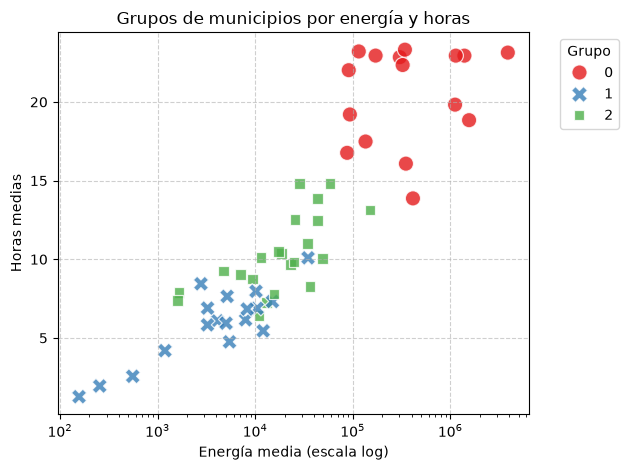

In [22]:
sns.scatterplot(data=df_mpio, x="energia_media", y="horas_media", hue="cluster",
    style="cluster", palette="Set1", s=120, alpha=0.8)
plt.xscale("log")
plt.title("Grupos de municipios por energía y horas")
plt.xlabel("Energía media (escala log)")
plt.ylabel("Horas medias")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Grupo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Municipios por grupo

In [23]:
for cluster in perfiles.index:
    lista = sorted(df_mpio[df_mpio["cluster"] == cluster].index.tolist())
    print(f"Grupo {cluster} ({len(lista)} municipios):")
    print(", ".join(lista), "\n")

Grupo 1 (18 municipios):
bojayá (bellavista), el charco, francisco pizarro, la tola, lópez (micay), magüí, medio atrato, medio san juan, mosquera, olaya herrera, quibdó, riosucio, río quito, santa bárbara, sipí, timbiquí, trinidad, tumaco 

Grupo 2 (22 municipios):
alto baudó, bajo baudó, barrancominas, bojayá, buenaventura, cartagena de indias, cartagena del chairá, carurú, el litoral del san juan, guapi, istmina, novita, nuquí, roberto payán, san andrés de tumaco, san josé del guaviare, san vicente del caguán, taraira, tarapacá, unguía, uribia, vigía del fuerte 

Grupo 0 (16 municipios):
acandí, bahía solano, ciénaga, cumaribo, inírida, juradó, la primavera, leticia, mapiripán, miraflores, mitú, providencia, puerto carreño, puerto leguízamo, puerto nariño, santa rosalía 



### Estabilidad del modelo

El presente análisis permite verificar que los grupos no dependen del azar: el modelo es estable ante la semilla. En 5 inicializaciones, 4 replican idéntica asignación (ARI = 1,0) y una difiere en un municipio (ARI = 0,945).

## Cierre

1) El riesgo energético se resume en cuatro perfiles ordenados por disponibilidad. 2) El grupo crítico concentra la mayoría de municipios con pocas horas y bajo consumo. 3) Cada perfil exige lineamientos diferenciados: ampliación de cobertura, respaldo con FNCER o consolidación del servicio. Estos grupos alimentan el tablero de control de la investigación.